### Ai Financial Data analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns



In [2]:
df=pd.read_csv("ai_financial_market_daily_realistic_synthetic.csv")
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [19]:
df["Date"]=pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [21]:
df['year']=df['Date'].dt.year
df.head(2)


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


### 1) How much amount the companies spent on R & D ?

In [7]:
RD=df.groupby("Company")["R&D_Spending_USD_Mn"].sum()
RD

Company
Google    423341.14
Meta      264533.07
OpenAI     26482.77
Name: R&D_Spending_USD_Mn, dtype: float64

Text(0.5, 0, 'Company')

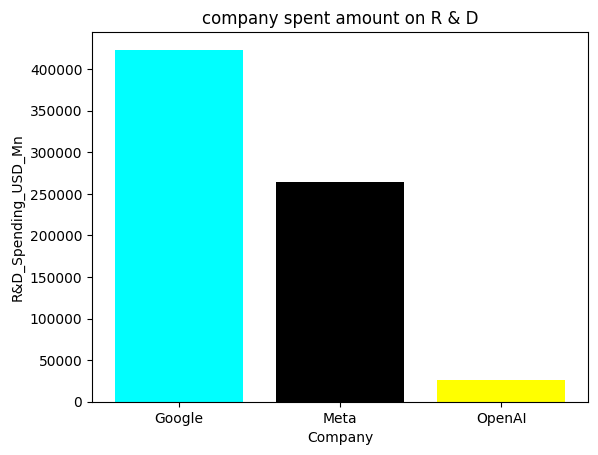

In [13]:
plt.bar(RD.index,RD.values,color=['cyan','black','yellow'])
plt.title("company spent amount on R & D")
plt.ylabel("R&D_Spending_USD_Mn")
plt.xlabel("Company")

### 2) Revenue Earned by the companies

In [24]:
rev=df.groupby("Company")["AI_Revenue_USD_Mn"].sum()  
rev

Company
Google    284498.38
Meta      189621.82
OpenAI      9462.89
Name: AI_Revenue_USD_Mn, dtype: float64

Text(0.5, 0, 'Company')

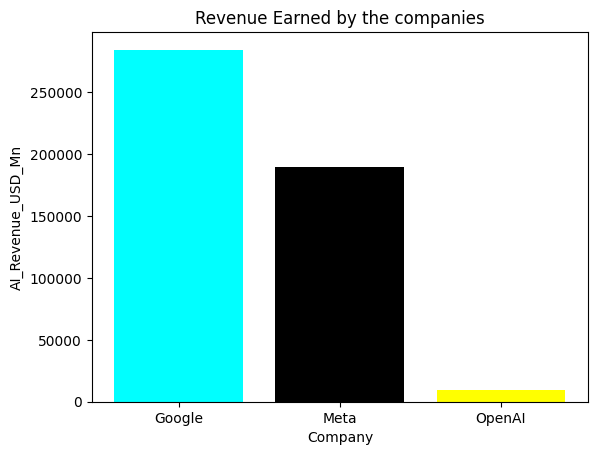

In [25]:
plt.bar(rev.index,rev.values,color=['cyan','black','yellow'])
plt.title("Revenue Earned by the companies")
plt.ylabel("AI_Revenue_USD_Mn")
plt.xlabel("Company")

### 3) Date-wise Impact on the Stock

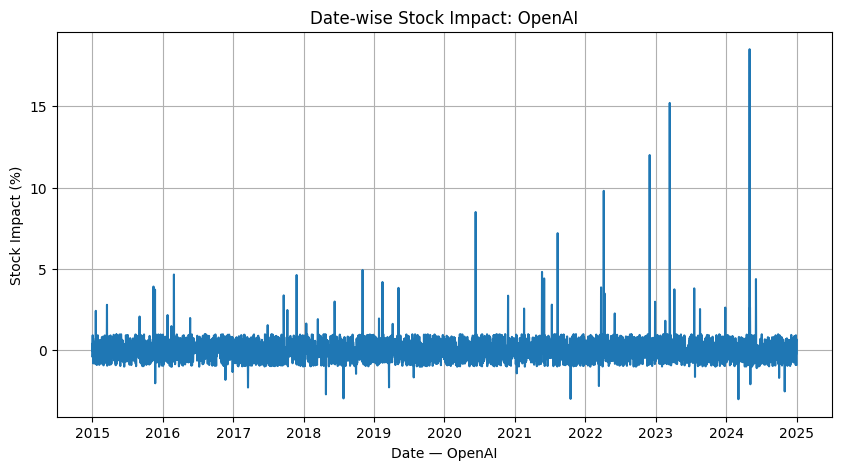

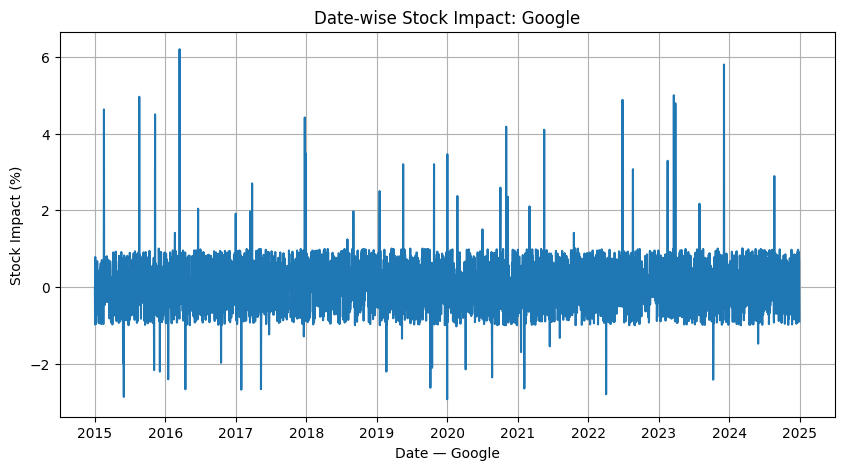

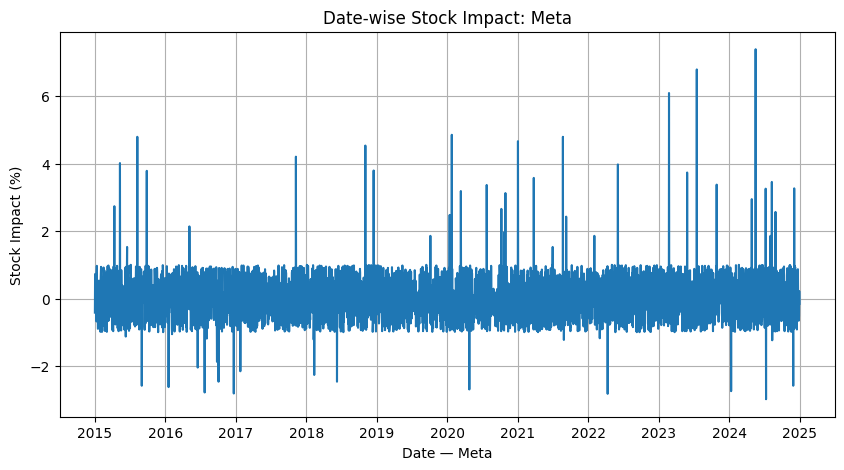

In [31]:


# Unique companies list nikal lo
companies = df["Company"].unique()

for company in companies:
    temp = df[df["Company"] == company]   # Filter each company
    
    plt.figure(figsize=(10,5))
    plt.plot(temp["Date"], temp["Stock_Impact_%"])
    plt.xlabel(f"Date — {company}")
    plt.ylabel("Stock Impact (%)")
    plt.title(f"Date-wise Stock Impact: {company}")
    plt.grid(True)
    plt.show()



### 4) Events when Maximum Stock Impact was observed

In [34]:
max_value = df["Stock_Impact_%"].max()
max_value



np.float64(18.5)

In [35]:
max_events = df[df["Stock_Impact_%"] == max_value]
max_events

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
3408,2024-05-01,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.5,2024


### 5) AI Revenue Growth of the companies


In [38]:
df.groupby("Company")["AI_Revenue_Growth_%"].agg(["min", "max", "mean", "sum"])


,min,max,mean,sum
Company,,,,
Google,-4.34,419.88,159.602313,583027.25
Meta,-7.81,423.01,159.542223,582807.74
OpenAI,-155.43,565.50,159.043427,580985.64


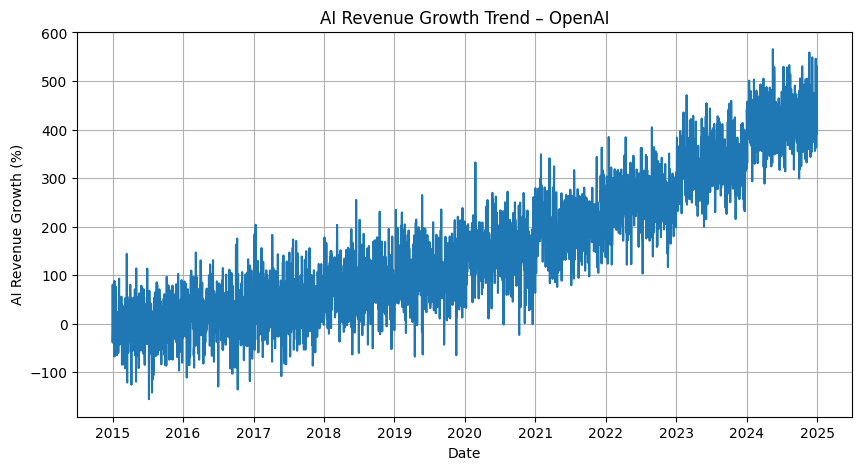

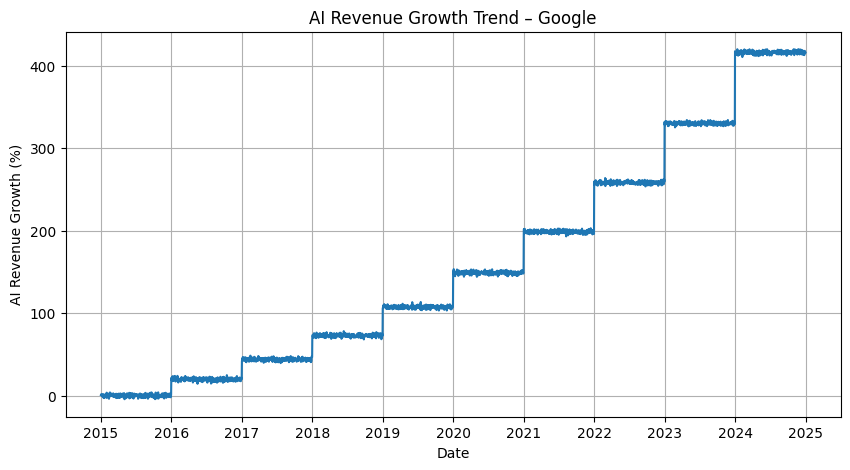

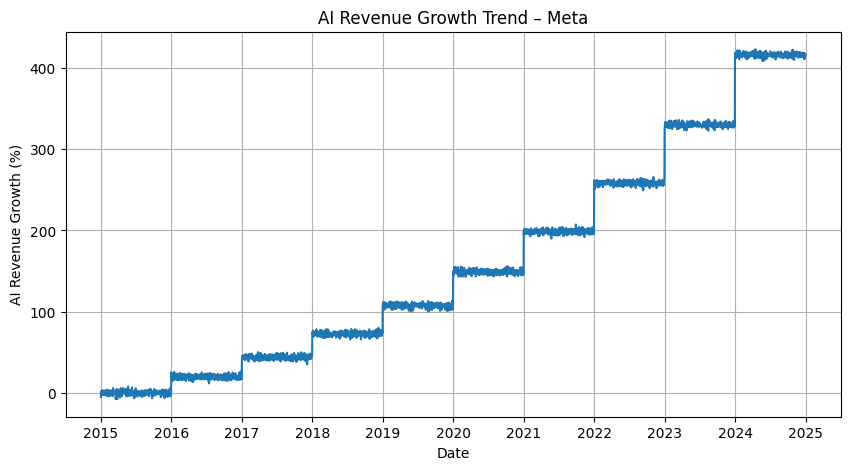

In [39]:
for company in df["Company"].unique():
    temp = df[df["Company"] == company]
    
    plt.figure(figsize=(10,5))
    plt.plot(temp["Date"], temp["AI_Revenue_Growth_%"])
    plt.title(f"AI Revenue Growth Trend – {company}")
    plt.xlabel("Date")
    plt.ylabel("AI Revenue Growth (%)")
    plt.grid(True)
    plt.show()

### 6) Correlation between the columns

In [40]:
df.corr(numeric_only=True)


,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,year
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.297701
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.526478
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.952199
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.016525
year,0.297701,0.526478,0.952199,0.016525,1.000000


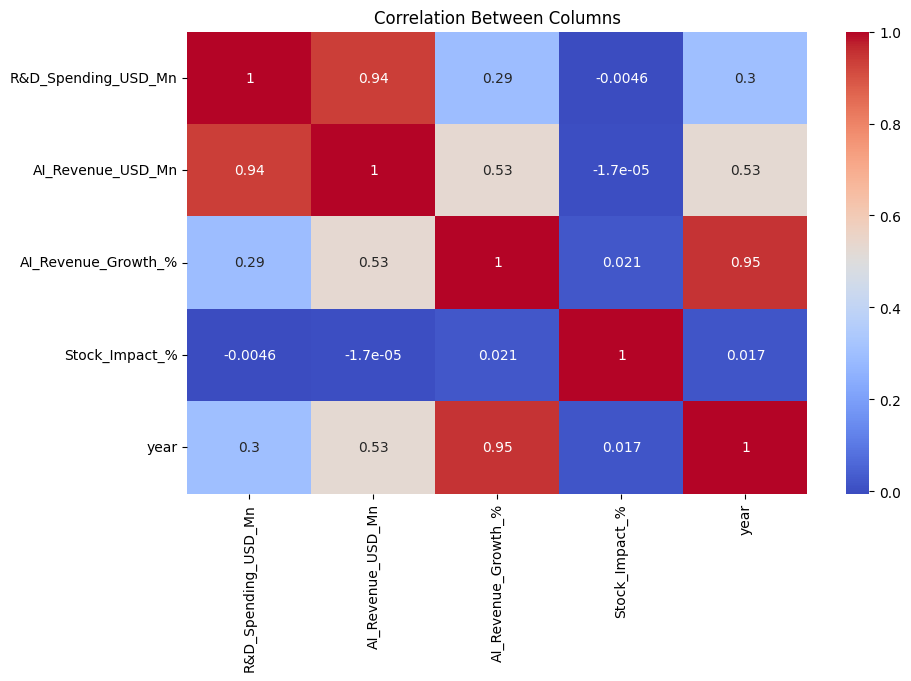

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Columns")
plt.show()

### 7) Expenditure vs Revenue year-by-year

In [43]:
yearly_summary = df.groupby("year")[["R&D_Spending_USD_Mn", "AI_Revenue_USD_Mn"]].sum()
yearly_summary


,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn
year,,
2015,49304.23,18623.21
2016,53349.94,22361.20
2017,57475.12,26776.80
2018,62002.16,32164.44
2019,67071.51,38580.32
2020,72602.53,46456.19
2021,78207.32,55591.14
2022,84390.17,66674.24
2023,91193.92,80041.64


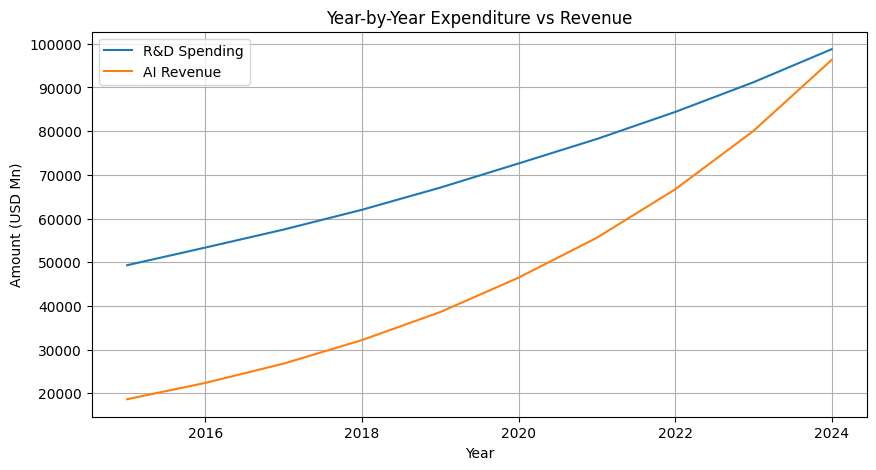

In [44]:
yearly = df.groupby("year")[["R&D_Spending_USD_Mn", "AI_Revenue_USD_Mn"]].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly["R&D_Spending_USD_Mn"], label="R&D Spending")
plt.plot(yearly.index, yearly["AI_Revenue_USD_Mn"], label="AI Revenue")
plt.xlabel("Year")
plt.ylabel("Amount (USD Mn)")
plt.title("Year-by-Year Expenditure vs Revenue")
plt.legend()
plt.grid(True)
plt.show()

### 8) Event Impact Analysis

In [45]:
event_impact = df.groupby("Event")["Stock_Impact_%"].mean().sort_values(ascending=False)
event_impact


Event
GPT-5 release (predicted)          18.500000
GPT-4 release                      15.200000
ChatGPT (GPT-3.5) launch           12.000000
DALL·E 2 release                    9.800000
GPT-3 release                       8.500000
LLaMA 3 release (predicted)         7.400000
Codex release                       7.200000
LLaMA 2 release                     6.800000
AlphaGo beats Lee Sedol             6.200000
LLaMA 1 release                     6.100000
Gemini AI release                   5.800000
Bard chatbot launch                 5.000000
TensorFlow open-source release      4.500000
GPT-2 release                       4.200000
MUM Search Model launch             4.100000
BERT for Search launch              3.200000
GPT-1 release                       3.000000
Cloud AI launch                     1.215185
AI ethics policy update             1.111852
AI Ads Optimization upgrade         0.983125
AI-powered search update            0.674063
AI partnership deal                 0.666562
AI s

### 9) Change in the index wrt Year & Company

In [46]:
change_index = df.pivot_table(
    values="Stock_Impact_%",
    index="year",
    columns="Company",
    aggfunc="mean"
)
change_index


Company,Google,Meta,OpenAI
year,,,
2015,-0.030192,0.024411,0.040795
2016,0.055492,-0.042896,0.051093
2017,0.026795,-0.014767,-0.010712
2018,0.068795,0.036548,0.017096
2019,0.000466,-0.007342,0.020411
2020,-0.000301,0.002404,0.011038
2021,0.010384,-0.019425,0.052137
2022,0.063671,0.031370,0.105945
2023,0.045315,0.035151,0.082904
